In [ ]:
import pandas as pd
import matplotlib as plt
import seaborn  as sns
import numpy as np

Analiza rozwoju kanałów w czasie

In [ ]:
#przygotowanie danych 

kanalZero = pd.read_csv("../data/raw/KanalZero_videos_info.csv")
orb = pd.read_csv("../data/raw/ORB_videos_info.csv")
konopsky = pd.read_csv("../data/raw/Konopskyy_videos_info.csv")

kanaly = [kanalZero, orb, konopsky]


kanaly_dict = {
    "Kanał Zero": kanalZero,
    "ORB": orb,
    "Konopskyy": konopsky
}

In [ ]:
# Zmiana jednostek czasu trwania filmiku

for df in kanaly:
   duration_time = pd.to_timedelta(df['duration'])
   df['duration_minutes'] = (duration_time.dt.total_seconds() /60).round(2)
print(kanalZero)


          video_id channel_name  \
0      p3xGa6yKxxM    KanalZero   
1      DGhEVGCr8kc    KanalZero   
2      HShngPHm-rY    KanalZero   
3      FBGv4bTHCuI    KanalZero   
4      SyAkC5NR41Q    KanalZero   
...            ...          ...   
11665  gfSAmRC6ymU    KanalZero   
11666  9uuojyjXzv0    KanalZero   
11667  02OwcddCyCM    KanalZero   
11668  b9LF33G9BLs    KanalZero   
11669  GZnPCn3X6NQ    KanalZero   

                                                   title  \
0      KRZYSZTOF ŚMISZEK I AGNIESZKA BURZYŃSKA - PORA...   
1                            OFICJALNY POCZĄTEK ZERO TV!   
2                  FARMY TROLLI WSPOMAGAJĄ MISZALSKIEGO?   
3      REFERENDUM W KRAKOWIE, INTERNETOWE TROLLE ZNIE...   
4      CO DALEJ Z AMERYKAŃSKIM WOJSKIEM? I TELEWIZYJN...   
...                                                  ...   
11665  TOMASZ ROŻEK W KANALE ZERO! #kanalzero #shorts...   
11666  MONIKA GOŹDZIALSKA W KANALE ZERO! #kanalzero #...   
11667  TEDE W KANALE ZERO! #kanalzero #

Analiza wyświetleń w czasie dla każdego kanału 

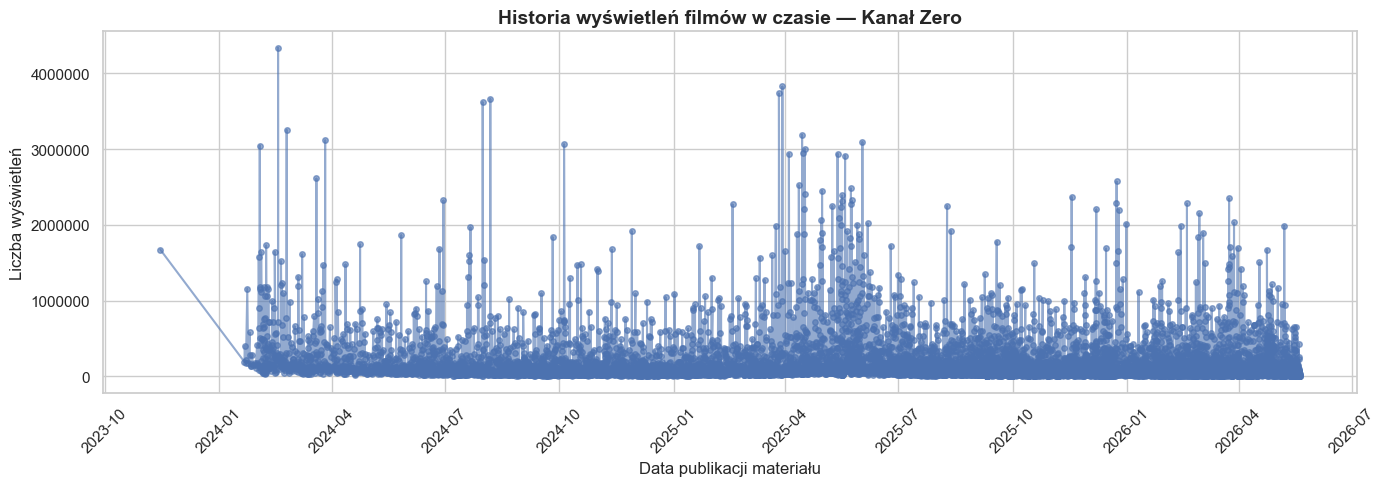

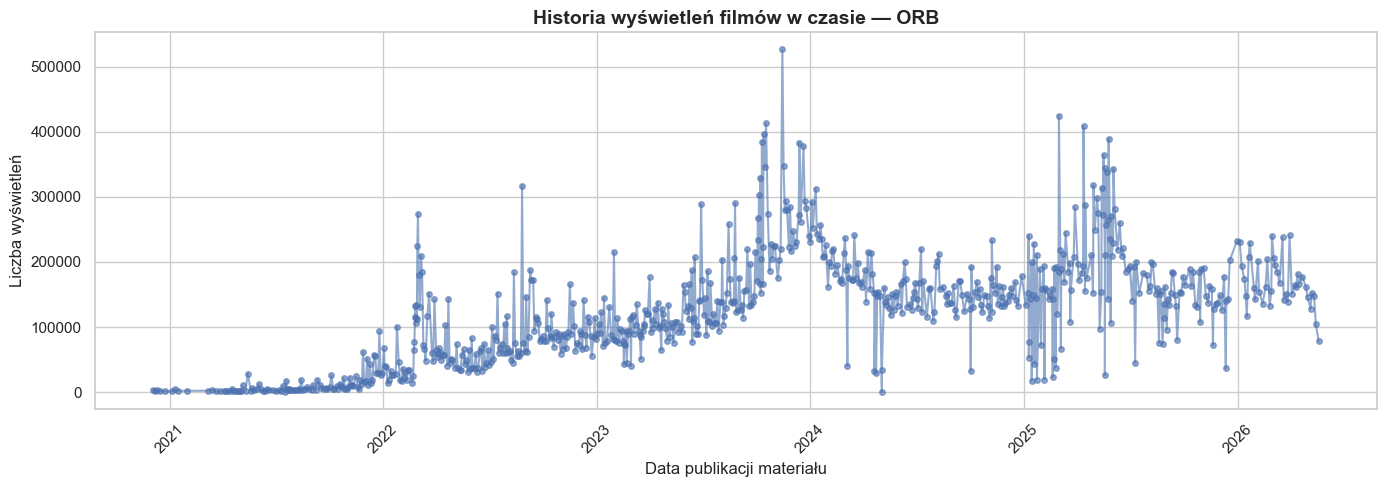

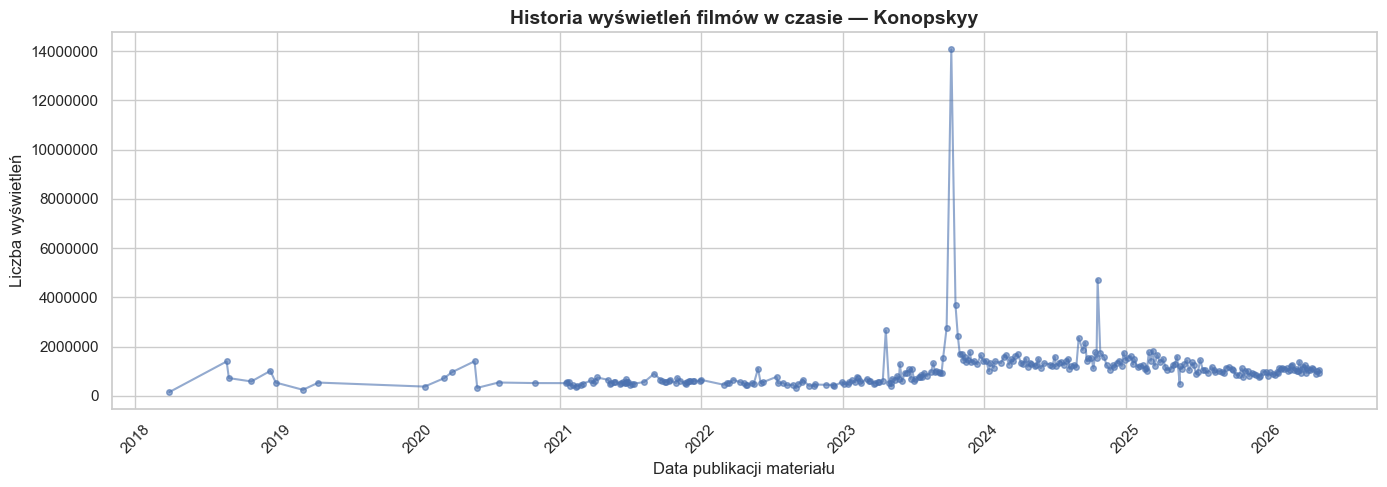

In [ ]:


for name, df in kanaly_dict.items():
    df['published_at'] = pd.to_datetime(df['published_at'])
    df.sort_values('published_at', inplace=True)

for name, df in kanaly_dict.items():
    plt.figure(figsize=(14, 5))
    
    plt.plot(df['published_at'], df['view_count'], marker='o', linestyle='-', alpha=0.6, markersize=4)
    
    plt.title(f'Historia wyświetleń filmów w czasie — {name}', fontsize=14, fontweight='bold')
    plt.xlabel('Data publikacji materiału', fontsize=12)
    plt.ylabel('Liczba wyświetleń', fontsize=12)
    plt.ticklabel_format(style='plain', axis='y')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [ ]:
# obcinamy shorty poniżej trzech minut 
for i, df in enumerate(kanaly):
    kanaly[i] = df[df['duration_minutes'] > 3].copy()

kanalZero = kanaly[0]
orb = kanaly[1]
konopsky = kanaly[2]

kanalZero.count()


video_id            5885
channel_name        5885
title               5885
published_at        5885
view_count          5885
like_count          5885
comment_count       5885
duration            5885
category_id         5885
duration_minutes    5885
dtype: int64

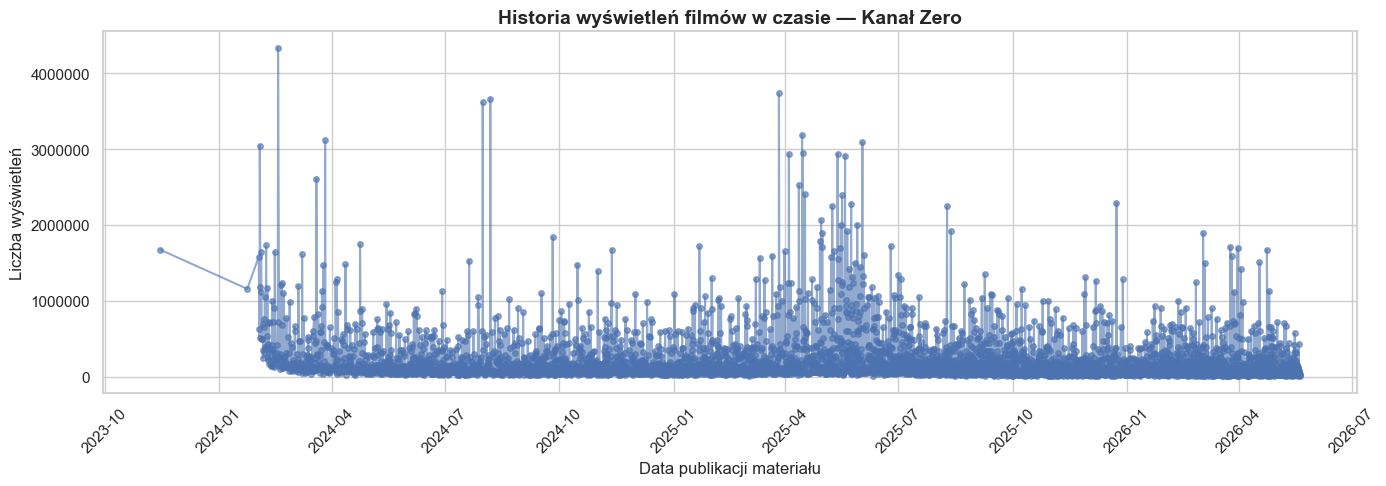

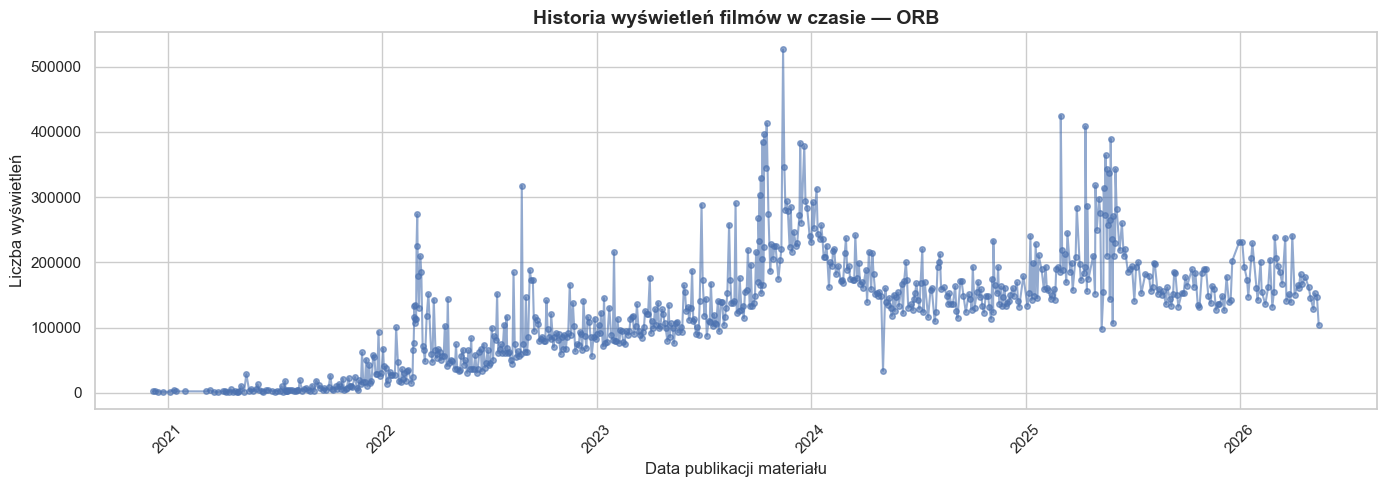

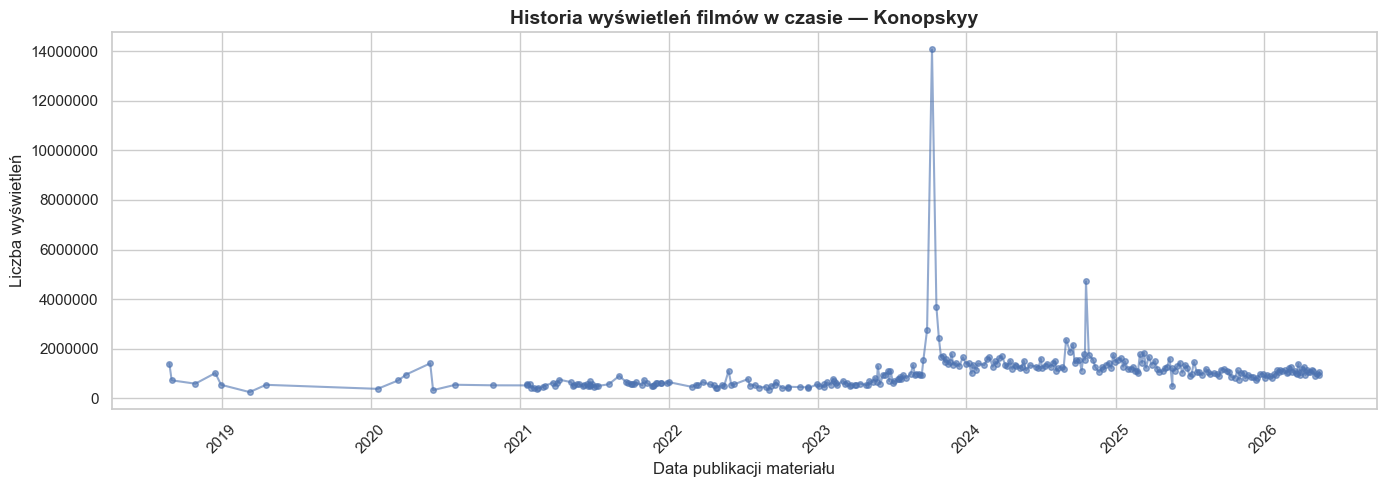

In [ ]:

for name, df in kanaly_dict.items():
    df['published_at'] = pd.to_datetime(df['published_at'])
    df.sort_values('published_at', inplace=True)

for name, df in kanaly_dict.items():
    plt.figure(figsize=(14, 5))
    
    plt.plot(df['published_at'], df['view_count'], marker='o', linestyle='-', alpha=0.6, markersize=4)
    
    plt.title(f'Historia wyświetleń filmów w czasie — {name}', fontsize=14, fontweight='bold')
    plt.xlabel('Data publikacji materiału', fontsize=12)
    plt.ylabel('Liczba wyświetleń', fontsize=12)
    plt.ticklabel_format(style='plain', axis='y')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

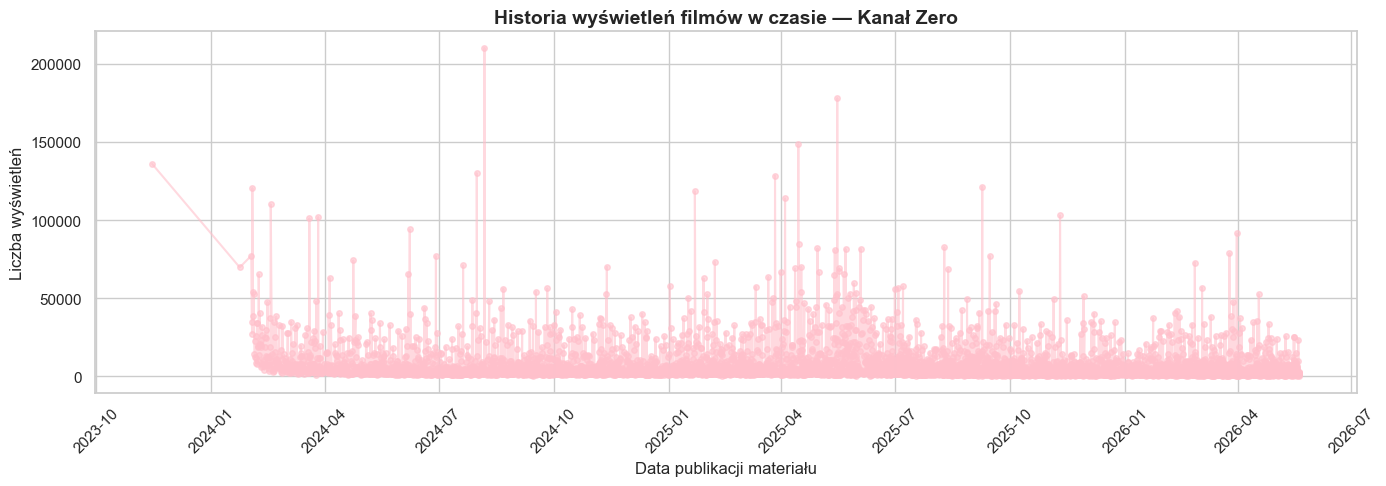

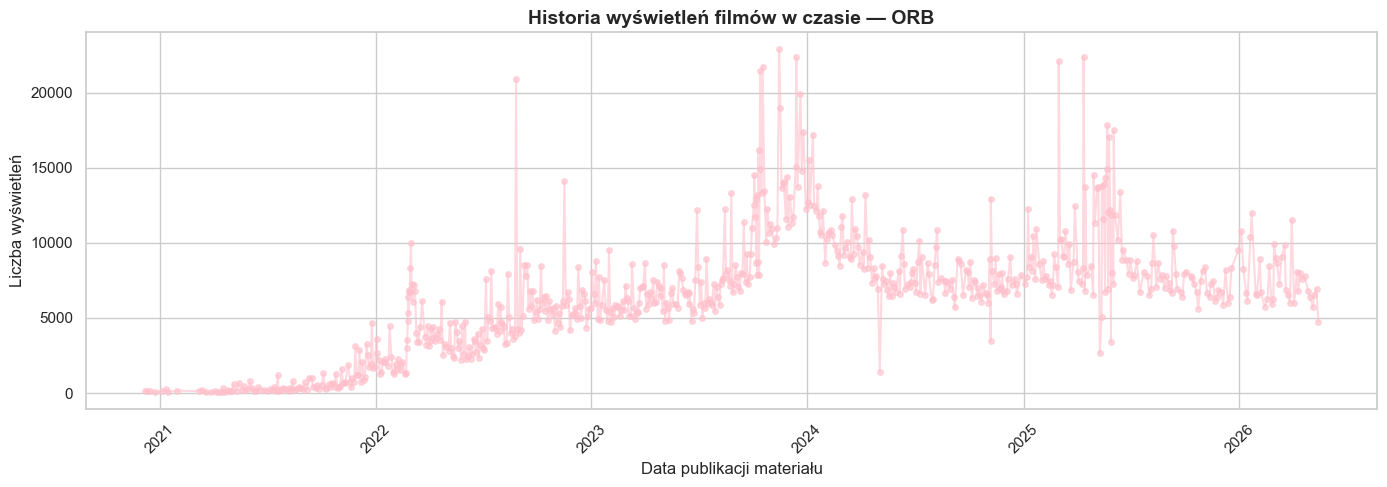

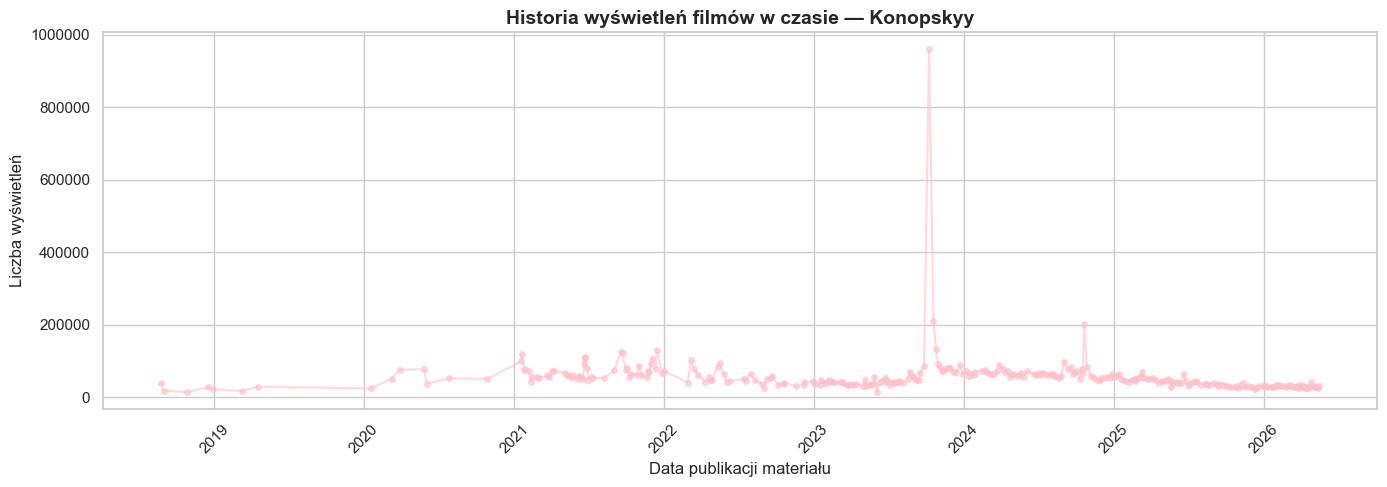

In [40]:
for name, df in kanaly_dict.items():
    plt.figure(figsize=(14, 5))
    
    plt.plot(df['published_at'], df['like_count'], color='pink',marker='o', linestyle='-', alpha=0.6, markersize=4)
    
    plt.title(f'Historia lików filmów w czasie — {name}', fontsize=14, fontweight='bold')
    plt.xlabel('Data publikacji materiału', fontsize=12)
    plt.ylabel('Liczba wyświetleń', fontsize=12)
    plt.ticklabel_format(style='plain', axis='y')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

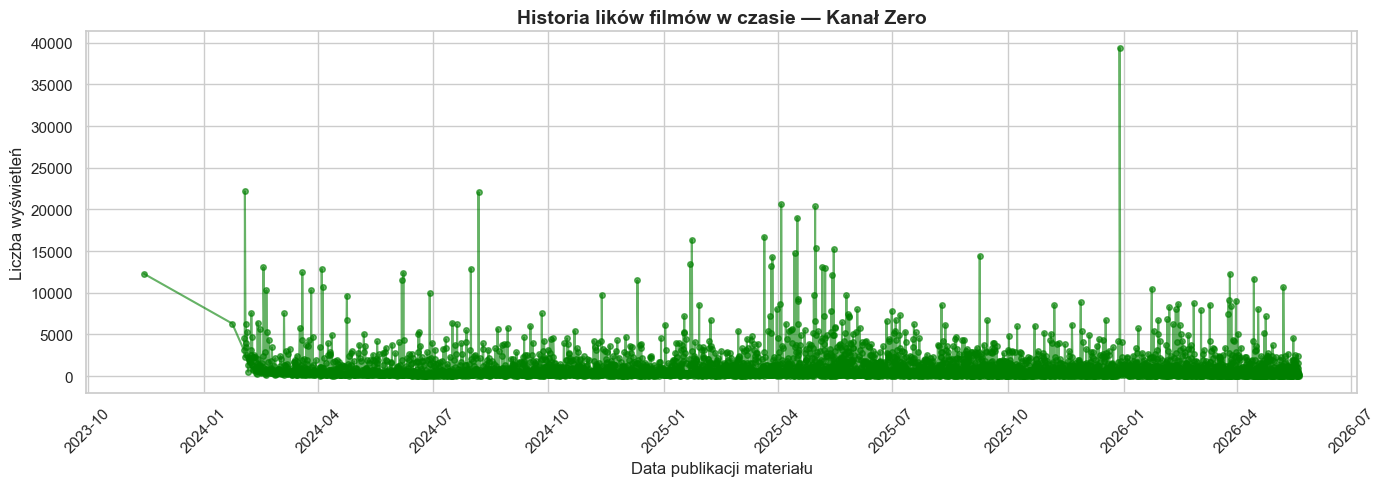

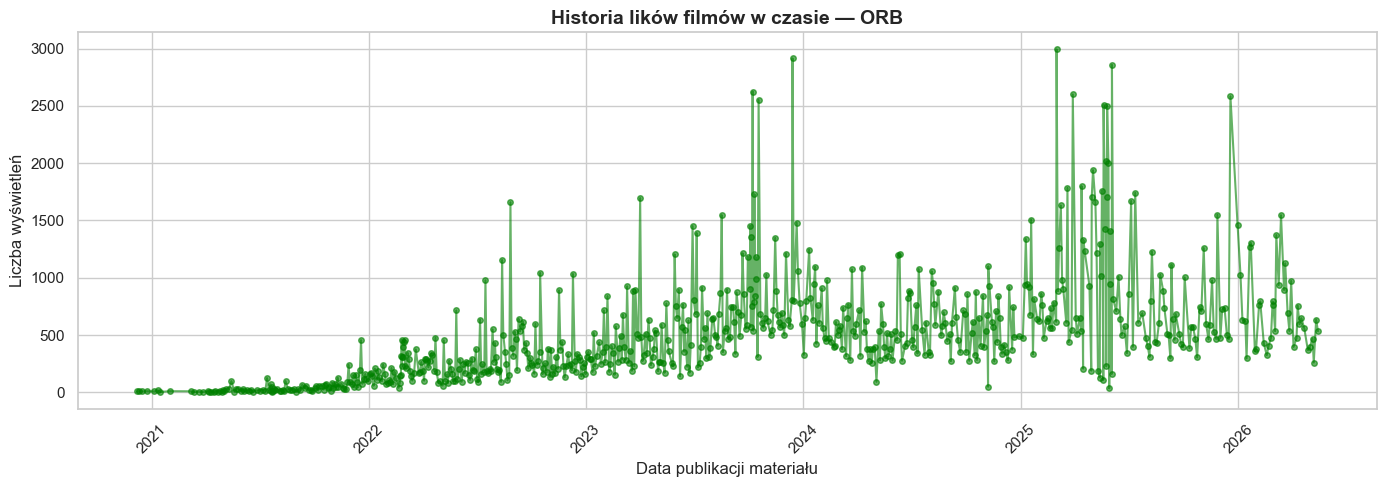

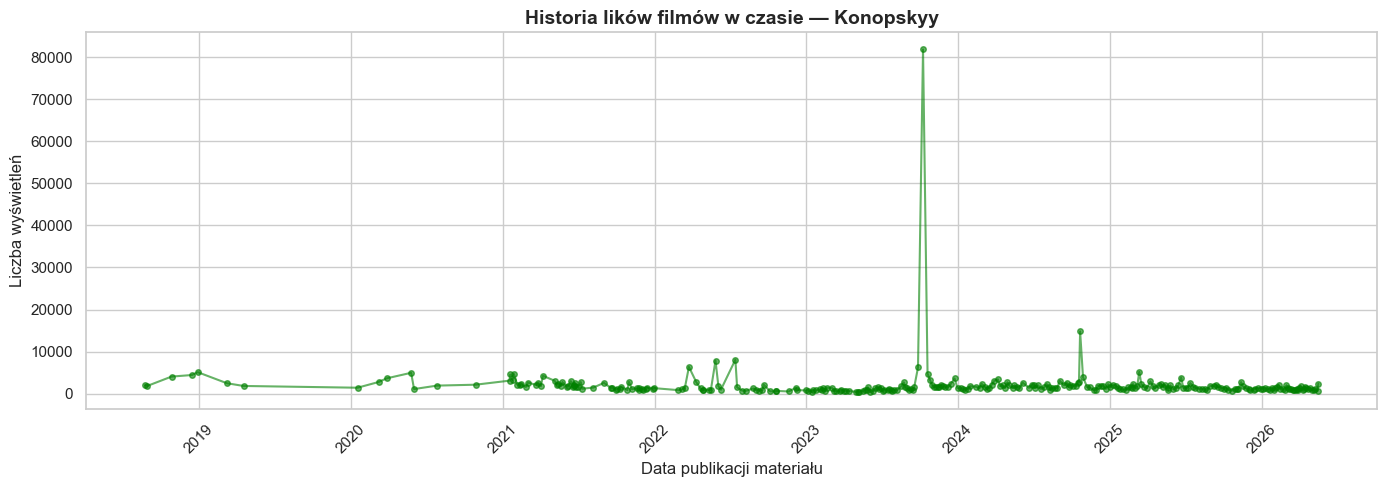

In [41]:
for name, df in kanaly_dict.items():
    plt.figure(figsize=(14, 5))
    
    plt.plot(df['published_at'], df['comment_count'], color='green',marker='o', linestyle='-', alpha=0.6, markersize=4)
    
    plt.title(f'Historia lików filmów w czasie — {name}', fontsize=14, fontweight='bold')
    plt.xlabel('Data publikacji materiału', fontsize=12)
    plt.ylabel('Liczba wyświetleń', fontsize=12)
    plt.ticklabel_format(style='plain', axis='y')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

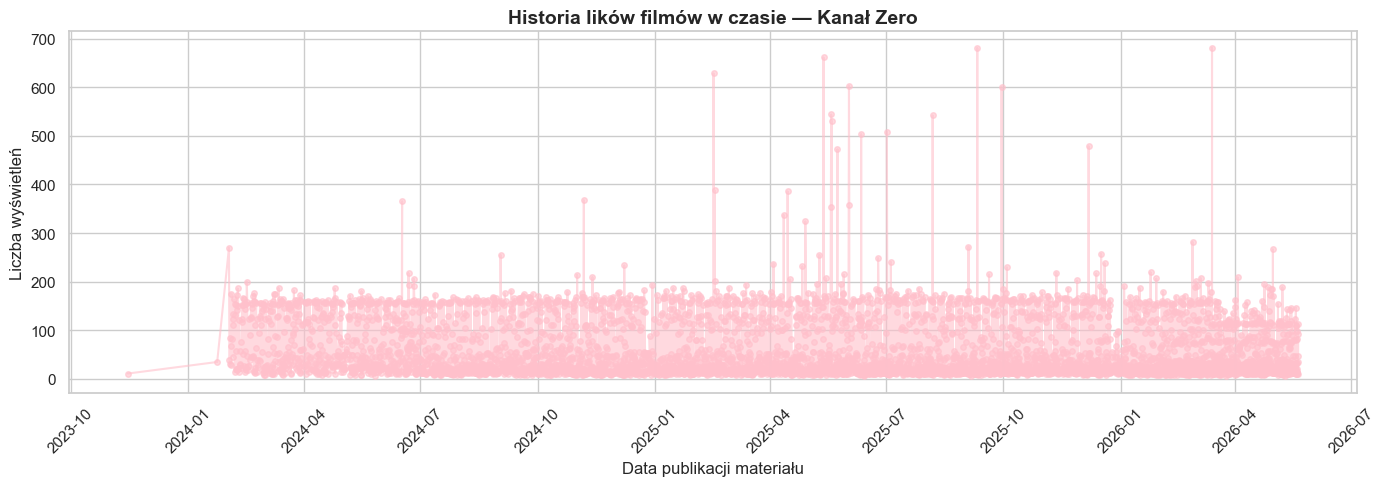

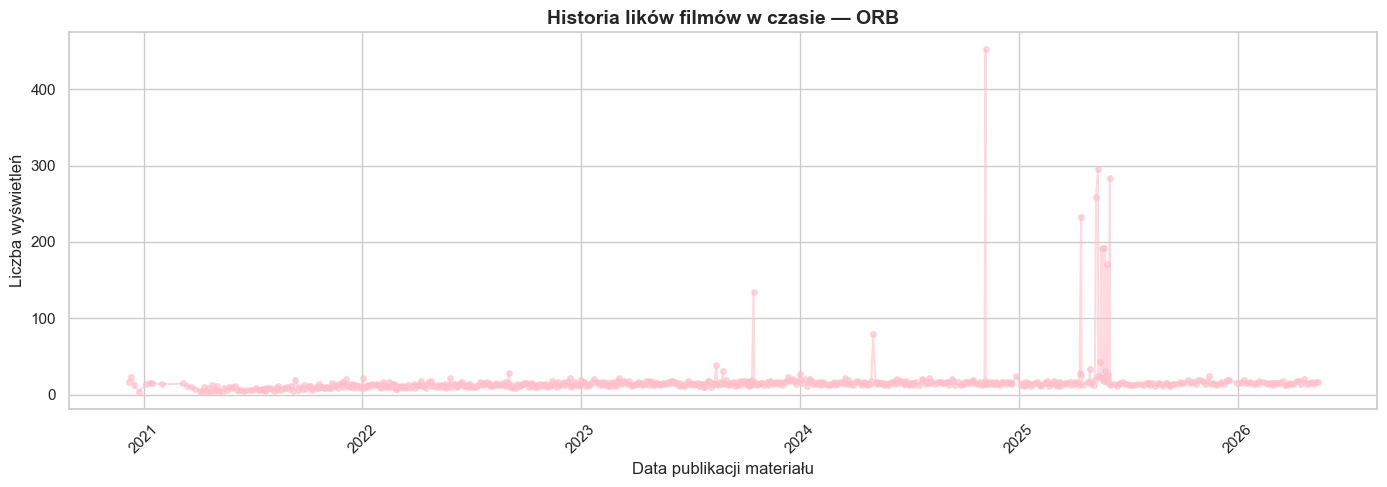

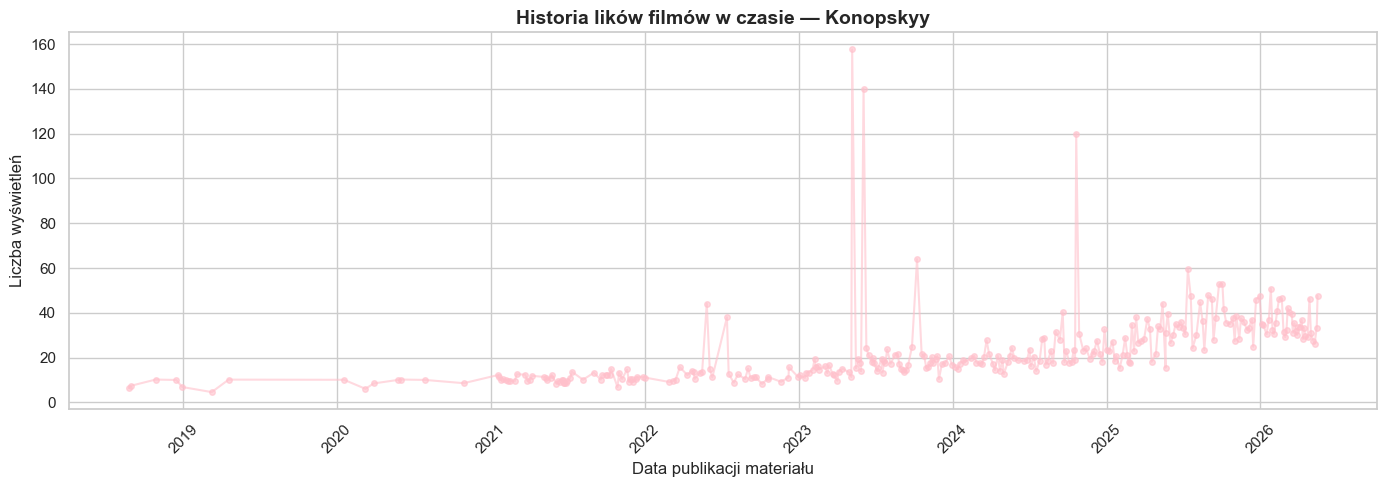

In [42]:
for name, df in kanaly_dict.items():
    plt.figure(figsize=(14, 5))
    
    plt.plot(df['published_at'], df['duration_minutes'], color='pink',marker='o', linestyle='-', alpha=0.6, markersize=4)
    
    plt.title(f'Historia lików filmów w czasie — {name}', fontsize=14, fontweight='bold')
    plt.xlabel('Data publikacji materiału', fontsize=12)
    plt.ylabel('Liczba wyświetleń', fontsize=12)
    plt.ticklabel_format(style='plain', axis='y')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [54]:
for name, df in kanaly_dict.items():
    df['like_ratio_%'] = (df['like_count'] / df['view_count'] * 100).round(2)
    df['comment_ratio_%'] = (df['comment_count'] / df['view_count'] *100).round(2)
    
    print(f"Średni wskaźnik polubień {name} (Likes/Views): {df['like_ratio_%'].mean():.2f}%")
    print(f"Średni wskaźnik komentarzy {name} (Comments/Views): {df['comment_ratio_%'].mean():.2f}%")
    
    

Średni wskaźnik polubień Kanał Zero (Likes/Views): 3.73%
Średni wskaźnik komentarzy Kanał Zero (Comments/Views): 0.53%
Średni wskaźnik polubień ORB (Likes/Views): 5.59%
Średni wskaźnik komentarzy ORB (Comments/Views): 0.41%
Średni wskaźnik polubień Konopskyy (Likes/Views): 6.30%
Średni wskaźnik komentarzy Konopskyy (Comments/Views): 0.20%


In [49]:
kolumny_analizy = ['duration_minutes', 'view_count', 'like_count', 'comment_count']

zestawienie_stats = {}

for name, df in kanaly_dict.items():
    zestawienie_stats[name] = df[kolumny_analizy].describe()

df_potezny = pd.concat(zestawienie_stats, axis=0)

formatowanie = {
    'view_count': '{:,.0f}',
    'like_count': '{:,.0f}',
    'duration_minutes': '{:,.2f}',
    'comment_count' :' {:,.0f}'
}

df_potezny.style.format(formatowanie)

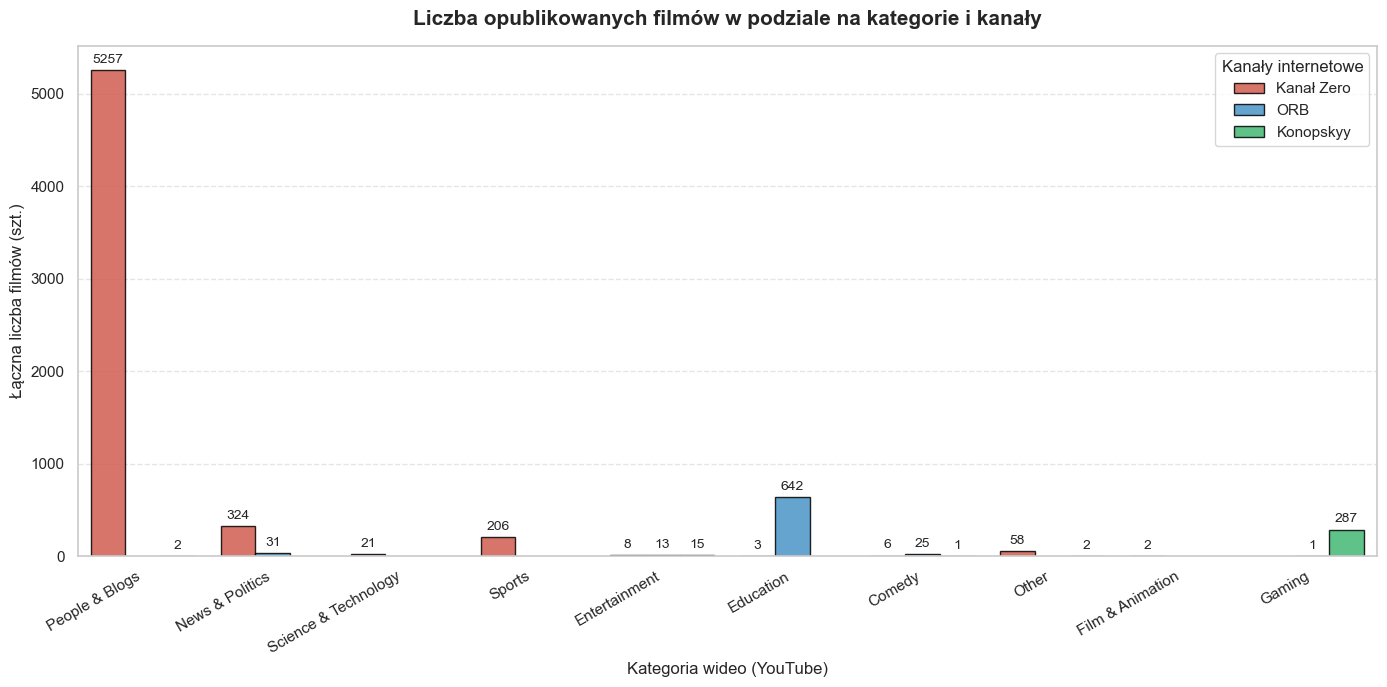

In [ ]:


category_map = {
    22: 'People & Blogs',
    24: 'Entertainment',
    25: 'News & Politics',
    1: 'Film & Animation',
    10: 'Music',
    17: 'Sports',
    20: 'Gaming',
    23: 'Comedy',
    26: 'Howto & Style',
    27: 'Education',
    28: 'Science & Technology'
}

kanalZero['channel'] = 'Kanał Zero'
orb['channel'] = 'ORB'
konopsky['channel'] = 'Konopskyy'

wszystkie_kanaly = pd.concat([kanalZero, orb, konopsky])

wszystkie_kanaly['category_id'] = wszystkie_kanaly['category_id'].astype(int)
wszystkie_kanaly['category_name'] = wszystkie_kanaly['category_id'].map(category_map)

wszystkie_kanaly['category_name'] = wszystkie_kanaly['category_name'].fillna('Other')

plt.figure(figsize=(14, 7))

trzy_kolory = ['#e74c3c', '#3498db', '#2ecc71'] 

ax = sns.countplot(
    data=wszystkie_kanaly, 
    x='category_name', 
    hue='channel', 
    palette=trzy_kolory,
    edgecolor='black',
    alpha=0.85
)

plt.title('Liczba opublikowanych filmów w podziale na kategorie i kanały', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Kategoria wideo (YouTube)', fontsize=12)
plt.ylabel('Łączna liczba filmów (szt.)', fontsize=12)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3, fontsize=10)

plt.legend(title='Kanały internetowe', fontsize=11, title_fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=30, ha='right')


In [62]:
for name, df in kanaly_dict.items():
    prog_viralu = df['view_count'].quantile(0.90)
    df['is_viral'] = df['view_count'] > prog_viralu
    df['video_type'] = df['is_viral'].map({False: 'Regular', True: 'Viral'})
    srednia_dlugosc = df.groupby('video_type')['duration_minutes'].mean()
    print(srednia_dlugosc.round(2))

video_type
Regular    53.87
Viral      70.72
Name: duration_minutes, dtype: float64
video_type
Regular    16.21
Viral      23.57
Name: duration_minutes, dtype: float64
video_type
Regular    21.65
Viral      29.64
Name: duration_minutes, dtype: float64


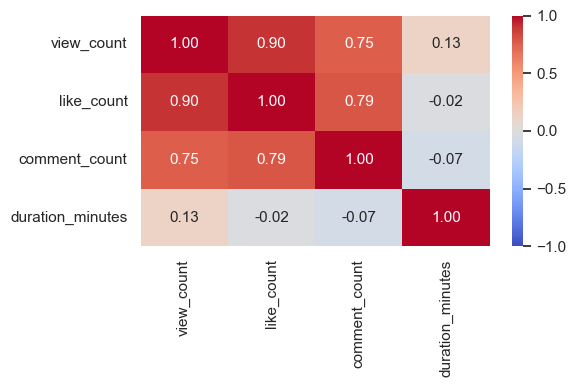

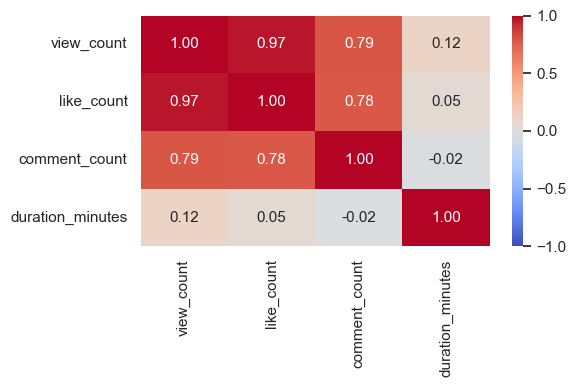

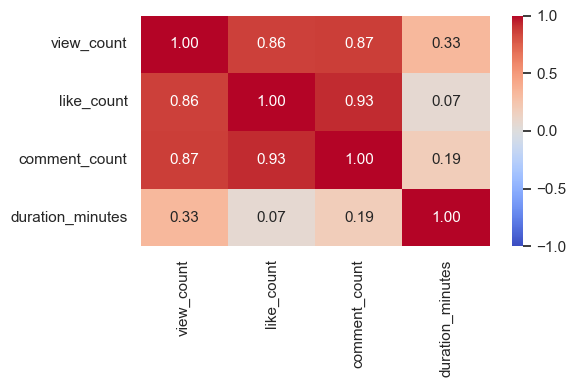

In [57]:


for name, df in kanaly_dict.items():
    plt.figure(figsize=(6, 4))
    korelacja = df[['view_count', 'like_count', 'comment_count', 'duration_minutes']].corr()
    
    sns.heatmap(korelacja, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
    plt.tight_layout()
    plt.show()

Kanał Zero - Współczynnik zmienności wyświetleń (CV): 1.50
ORB - Współczynnik zmienności wyświetleń (CV): 0.65
Konopskyy - Współczynnik zmienności wyświetleń (CV): 0.86
